In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

G = nx.karate_club_graph()

print("Graph loaded successfully")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Graph type:", type(G))
print("Connected:", nx.is_connected(G))

Graph loaded successfully
Nodes: 34
Edges: 78
Graph type: <class 'networkx.classes.graph.Graph'>
Connected: True


In [ ]:
degrees = dict(G.degree())
degree_centrality = nx.degree_centrality(G)

degree_df = pd.DataFrame({
    "node": list(G.nodes()),
    "club": [G.nodes[n]["club"] for n in G.nodes()],
    "degree": [degrees[n] for n in G.nodes()],
    "degree_centrality": [degree_centrality[n] for n in G.nodes()]
}).sort_values("degree", ascending=False)

degree_df.head(10)

,node,club,degree,degree_centrality
33,33,Officer,17,0.515152
0,0,Mr. Hi,16,0.484848
32,32,Officer,12,0.363636
2,2,Mr. Hi,10,0.303030
1,1,Mr. Hi,9,0.272727
3,3,Mr. Hi,6,0.181818
31,31,Officer,6,0.181818
23,23,Officer,5,0.151515
8,8,Mr. Hi,5,0.151515
13,13,Mr. Hi,5,0.151515


In [ ]:
betweenness = nx.betweenness_centrality(G, weight=None)
closeness = nx.closeness_centrality(G)
eigenvector = nx.eigenvector_centrality(G, max_iter=1000)
pagerank = nx.pagerank(G)

centrality_df = pd.DataFrame({
    "node": list(G.nodes()),
    "club": [G.nodes[n]["club"] for n in G.nodes()],
    "degree": [degrees[n] for n in G.nodes()],
    "degree_centrality": [degree_centrality[n] for n in G.nodes()],
    "betweenness": [betweenness[n] for n in G.nodes()],
    "closeness": [closeness[n] for n in G.nodes()],
    "eigenvector": [eigenvector[n] for n in G.nodes()],
    "pagerank": [pagerank[n] for n in G.nodes()]
})

centrality_df.sort_values("betweenness", ascending=False).head(10)

,node,club,degree,degree_centrality,betweenness,closeness,eigenvector,pagerank
0,0,Mr. Hi,16,0.484848,0.437635,0.568966,0.355483,0.088508
33,33,Officer,17,0.515152,0.304075,0.550000,0.373371,0.096980
32,32,Officer,12,0.363636,0.145247,0.515625,0.308651,0.075926
2,2,Mr. Hi,10,0.303030,0.143657,0.559322,0.317189,0.062767
31,31,Officer,6,0.181818,0.138276,0.540984,0.191036,0.041985
8,8,Mr. Hi,5,0.151515,0.055927,0.515625,0.227405,0.033382
1,1,Mr. Hi,9,0.272727,0.053937,0.485294,0.265954,0.057415
13,13,Mr. Hi,5,0.151515,0.045863,0.515625,0.226470,0.033474
19,19,Mr. Hi,3,0.090909,0.032475,0.500000,0.147911,0.013078
5,5,Mr. Hi,4,0.121212,0.029987,0.383721,0.079481,0.033810


In [ ]:
comparison = centrality_df[centrality_df["node"].isin([0, 33])].copy()
comparison

,node,club,degree,degree_centrality,betweenness,closeness,eigenvector,pagerank
0,0,Mr. Hi,16,0.484848,0.437635,0.568966,0.355483,0.088508
33,33,Officer,17,0.515152,0.304075,0.550000,0.373371,0.096980


In [ ]:
boundary_candidates = centrality_df[~centrality_df["node"].isin([0, 33])]
boundary_candidates.sort_values("betweenness", ascending=False).head(5)

,node,club,degree,degree_centrality,betweenness,closeness,eigenvector,pagerank
32,32,Officer,12,0.363636,0.145247,0.515625,0.308651,0.075926
2,2,Mr. Hi,10,0.303030,0.143657,0.559322,0.317189,0.062767
31,31,Officer,6,0.181818,0.138276,0.540984,0.191036,0.041985
8,8,Mr. Hi,5,0.151515,0.055927,0.515625,0.227405,0.033382
1,1,Mr. Hi,9,0.272727,0.053937,0.485294,0.265954,0.057415


In many runs of this analysis, node 32 appears as a strong boundary or bridge-like node.  
It has high degree and high betweenness, meaning it is connected to many others and also lies on many shortest paths between members.


##Density, clustering, and path-based metric

The graph is connected, so path-based metrics can be computed on the full graph.


In [ ]:
density = nx.density(G)
avg_clustering = nx.average_clustering(G)
diameter = nx.diameter(G)
avg_shortest_path = nx.average_shortest_path_length(G)
eccentricity = nx.eccentricity(G)

print("Density:", round(density, 4))
print("Average clustering:", round(avg_clustering, 4))
print("Diameter:", diameter)
print("Average shortest path length:", round(avg_shortest_path, 4))

ecc_df = pd.DataFrame({
    "node": list(eccentricity.keys()),
    "eccentricity": list(eccentricity.values())
}).sort_values("eccentricity")

ecc_df.head(10)

Density: 0.139
Average clustering: 0.5706
Diameter: 5
Average shortest path length: 2.4082


,node,eccentricity
0,0,3
1,1,3
2,2,3
3,3,3
13,13,3
8,8,3
31,31,3
19,19,3
7,7,4
6,6,4


## Visualization

Node size reflects betweenness centrality.  
Node color reflects club membership.


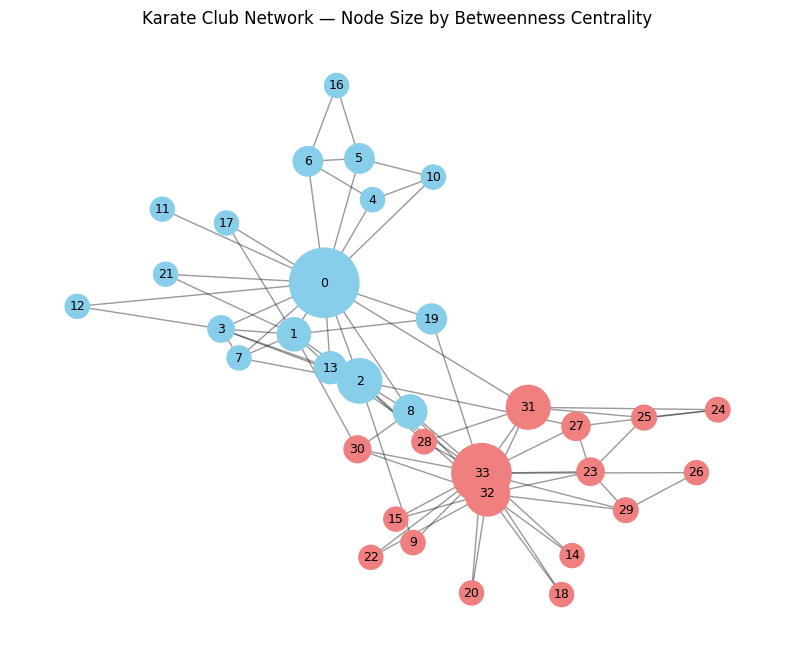

In [ ]:
pos = nx.spring_layout(G, seed=42)

club_colors = []
for n in G.nodes():
    if G.nodes[n]["club"] == "Mr. Hi":
        club_colors.append("skyblue")
    else:
        club_colors.append("lightcoral")

node_sizes = [300 + betweenness[n] * 5000 for n in G.nodes()]

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(G, pos, alpha=0.4)
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=club_colors,
    node_size=node_sizes
)
nx.draw_networkx_labels(G, pos, font_size=9)

plt.title("Karate Club Network — Node Size by Betweenness Centrality")
plt.axis("off")
plt.show()

## Interpretation

Nodes 0 and 33 are the most central actors in the Karate Club network because they have the highest degrees and represent the two main factions. Node 0 is especially important in the Mr. Hi group, while node 33 is central in the Officer group. Betweenness centrality highlights nodes that connect different parts of the graph, so it can identify boundary or bridge nodes rather than only popular nodes. In this network, node 32 is an important boundary-like node because it has high betweenness and is close to the Officer side while still helping connect paths across the network. The different metrics do not always agree because degree measures direct popularity, betweenness measures brokerage, closeness measures distance to all others, and eigenvector/PageRank reward connections to already important nodes.
